<a href="https://colab.research.google.com/github/speleos/Notebooks/blob/main/SUBMERSE_workshop_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In case that you use data from this Notebook as it is originally provided (network `3X2023`), do not forget to use the proper citation for attribution:

*   Afonso Loureiro (2024): GeoLab. GFZ Data Services. Dataset/DAS. doi:[10.14470/8K802502](https://doi.org/10.14470/8K802502)

First, we need to install all the necessary functions: `boto3` to access data archived in some S3 Object Storage, and `simpledas`, to parse and read OptoDAS raw data files. `obspy` will be needed to show how we can convert DAS data into common formats.

After you install the dependencies, the environment might need to be restarted.

If so, restart, and re-run from the top.

In [ ]:
try:
    import obspy
    import boto3
    import simpledas
    print("Environment ready.")
except ImportError:
    print("Installing dependencies...")
    !pip install obspy git+https://github.com/ASN-Norway/simpleDAS.git boto3

Environment ready.


Let's import some libraries

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

import os
import threading

from datetime import datetime, timedelta

from matplotlib import pyplot as plt

import numpy as np

import simpledas
from simpledas import h5pydict

import h5py
from h5py import File

import scipy.signal as sps
from scipy.signal import butter, filtfilt, find_peaks, spectrogram, resample_poly

import obspy
from obspy import UTCDateTime, Trace, Stream
from obspy.signal.cross_correlation import correlate as obspy_cc

from IPython.display import Image

import zlib
import base64

---
# **Example #0**
## Downloading data from S3 storage
---

For this notebook, we need to download data. We will use the open-access dataset from GeoLab (network 3X.2023), hosted at GEOFON.

It is very important to define who is actually hosting the data. Most of the examples you will find will be hosted in Amazon, but your Universities could also be providers of the S3 service.

In [ ]:
endpoint = 'https://s3.gfz-potsdam.de/'

Within `boto3` there are 2 ways to operate on the buckets and objects. Through a `resource` or a `client`. In this example below we use the `resource` to get the data.

In [ ]:
s3r = boto3.resource('s3', endpoint_url=endpoint, config=Config(signature_version=UNSIGNED))

Pay attention to the `UNSIGNED` value in the configuration. In this particular case, you will access data that does not require authentication. This is unusual in the S3 world. Usually you will be given a pair of keys (credentials) to operate with the service provider.

---

Once the `resource` is created, you can define the objects to operate with.
For instance, the `Bucket` where the 3X2023 data (GeoLab Madeira) are hosted.

In [ ]:
bucket = s3r.Bucket('gc.3x2023')

Let's define the time window to download.

In [ ]:
uncorrected_starttime = datetime(2023, 10, 29, 4, 50, 00)
uncorrected_endtime = datetime(2023, 10, 29, 4, 51, 10)

clock_offset=150 # positive values mean that the DAS clock is behind
starttime = uncorrected_starttime + timedelta(seconds=clock_offset)
endtime = uncorrected_endtime + timedelta(seconds=clock_offset)

print(f'Corrected start and end times: {starttime} - {endtime}')

Corrected start and end times: 2023-10-29 04:52:30 - 2023-10-29 04:53:40


Create auxiliary variables to loop through objects and keep the ones that lie within the time window. Here, we will check all objects that were created in the hour of the time window.

OptoDAS save a files every 10 seconds, and they are named according to the hour of the first sample, in directories named according to the date.

Example: ./DATA/20231029/dphi/045200.hdf5 corresponds to a file starting at 04:52:00 on 2023/10/29. The folder dphi indicates that we are dealing with phase differences ($dϕ$).

In [ ]:
prefix = starttime.strftime('%Y%m%d/dphi/%H')
h5start = starttime.strftime('%Y%m%d/dphi/%H%M%S.h5')
h5end = endtime.strftime('%Y%m%d/dphi/%H%M%S.h5')
files = list()
prevfile = None

Loop through `objects` and always add a previous file to keep the beginning of the time window. Stop as soon as the time window is gone. After the loop, add the last file that is missing.

In [ ]:
for obj in bucket.objects.filter(Prefix=prefix): #Filtering is much faster than listing the whole bucket
  # If time window is already gone then break
  if h5end < obj.key:
    break
  # If we are in the time window
  if h5start <= obj.key <= h5end:
    print(prevfile)
    files.append(prevfile)
  prevfile = obj.key

# If there was a file still pending
if prevfile is not None:
  files.append(prevfile)
  print(prevfile)


20231029/dphi/045229.hdf5
20231029/dphi/045239.hdf5
20231029/dphi/045249.hdf5
20231029/dphi/045259.hdf5
20231029/dphi/045309.hdf5
20231029/dphi/045319.hdf5
20231029/dphi/045329.hdf5
20231029/dphi/045339.hdf5


Use the `download_file` method to get some object(s) and save it physically in your local computer. Then, open it and extract the channel you want to display.

In [ ]:
data_folder = "./DATA/"
for f in files:
    # 1. Create the full local path e.g., `./DATA/dphi/20231029/dphi/045229.hdf5`
    local_full_path = os.path.join(data_folder, f)

    # 2. Check if file already exists
    if os.path.exists(local_full_path):
        print(f"Skipping: {f} already exists at {local_full_path}")
        continue  # Moves to the next file in the list

    # 3. Extract the directory part for folder creation
    local_folder = os.path.dirname(local_full_path)

    # 4. Create the directories
    os.makedirs(local_folder, exist_ok=True)

    # 5. Download the data
    print(f"Downloading file: {f}")
    try:
        bucket.download_file(Key=f, Filename=local_full_path)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading {f}: {e}")

Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.


Let's check if the data are in the right place.

In [ ]:
os.listdir("./DATA/20231029/dphi")

['045339.hdf5',
 '045229.hdf5',
 '045309.hdf5',
 '045239.hdf5',
 '045259.hdf5',
 '045249.hdf5',
 '045319.hdf5',
 '045329.hdf5']

While we work on the data we've just downloaded, we can run a background task to download a larger volume of data to be used later.

We've also improved the logic behind the prefix filtering in S3 to allow data from different hours to be downloaded.
Filtering ahead is much faster than listing the entire bucket.

First, we define a function based on the code above, redirecting the status messages to a log:

In [ ]:
status_log = []

def background_download_s3_data(starttime, endtime, bucket):
    files = []

    # 1. Generate all hourly prefixes between start and end
    # We use a set to ensure unique prefixes (in case start/end are in the same hour)
    prefixes = set()
    current = starttime
    # This loop ensures we grab the prefix for the start, the end,
    # and every hour in between
    while current.replace(minute=0, second=0) <= endtime:
        prefixes.add(current.strftime('%Y%m%d/dphi/%H'))
        current += timedelta(hours=1)

    # Define bounds for filtering
    h5start = starttime.strftime('%Y%m%d/dphi/%H%M%S.h5')
    h5end = endtime.strftime('%Y%m%d/dphi/%H%M%S.h5')

    # 2. Iterate through each prefix
    # S3 filter is much faster than listing the whole bucket
    for prefix in sorted(list(prefixes)):
        prevfile = None
        for obj in bucket.objects.filter(Prefix=prefix):
            # Same logic as before, but scoped to the current prefix
            if h5start <= obj.key <= h5end:
                if prevfile not in files: # Avoid duplicates at hour boundaries
                    files.append(prevfile)

            # Optimization: if we've passed the end time in this specific prefix
            if obj.key > h5end:
                break

            prevfile = obj.key

        # Catch the last file of the prefix if it was valid
        if prevfile and h5start <= prevfile <= h5end:
            if prevfile not in files:
                files.append(prevfile)

    status_log.append("Background Download Task Started!")
    status_log.append(f'Start and end times: {starttime} - {endtime}')
    status_log.append(f"Filtered Prefixes: {sorted(list(prefixes))}")
    status_log.append(f'Files to download: {files}')

    data_folder = "./DATA/"
    for f in [f for f in files if f]: # Filter out 'None' entries
        local_full_path = os.path.join(data_folder, f)
        if os.path.exists(local_full_path):
            status_log.append(f"Skipped {f}. Already exists.")
            continue

        os.makedirs(os.path.dirname(local_full_path), exist_ok=True)
        try:
            bucket.download_file(Key=f, Filename=local_full_path)
            status_log.append(f"Downloaded {f}.")
        except Exception as e:
            print(f"Error: {e}")
    print("Background Download Task Finished!")

Now we launch the background process to download 30 minutes of data. It should take around 10 minutes to run.

Note that we still need to correct for clock offset to ensure the time is close to the truth.

In [ ]:
# uncorrected_starttime = datetime(2023, 10, 27, 18, 30, 0)
# uncorrected_endtime = datetime(2023, 10, 27, 19, 0, 0)
uncorrected_starttime = datetime(2023, 10, 27, 17, 0, 0)
uncorrected_endtime = datetime(2023, 10, 27, 17, 30, 0)

background_starttime = uncorrected_starttime + timedelta(seconds=clock_offset)
background_endtime = uncorrected_endtime + timedelta(seconds=clock_offset)

print(f'Background download start and end times: {background_starttime} - {background_endtime}')

download_thread = threading.Thread(target=background_download_s3_data,\
                                   args=(background_starttime, background_endtime, bucket))
download_thread.start()

Background download start and end times: 2023-10-27 17:02:30 - 2023-10-27 17:32:30


While the background task is running, we'll open the first file we downloaded and check if there's any data.

We'll choose a channel close to the beach, where we are bound to find waves.

extracting channel no.500, from file ./DATA/20231029/dphi/045229.hdf5


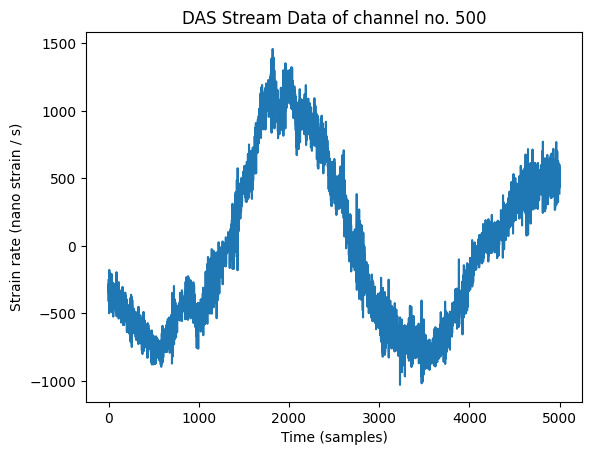

In [ ]:
channel = 500
stream = np.array([])
filename=os.path.join(data_folder,files[0])
fi = File(filename)
print(f'extracting channel no.{channel}, from file {filename}')
stream = np.append(stream, fi['data'][:, channel])

plt.plot(stream)
plt.xlabel("Time (samples)")
plt.ylabel("Strain rate (nano strain / s)")
plt.title(f'DAS Stream Data of channel no. {channel}')
plt.show()

Each file is 10 seconds long. Notice how we have 5000 samples. According to the data report (DOI: [10.26443/seismica.v4i2.1482](https://doi.org/10.26443/seismica.v4i2.1482)), data were acquired at a 500 Hz sampling rate.

We see waves at about 10 s period, which is what we would expect.
**Data seems good!**

---

Now, we'll leverage simpledas to load more than just one channel.

Let's begin with retriving acquisition parameters from the header.

In [ ]:
with h5py.File(os.path.join(data_folder,files[0]), "r") as hf_in:
            roi_step=hf_in['/demodSpec/roiDec'][0]
            first_chan = hf_in['/header/channels'][0]
            last_chan = hf_in['/header/channels'][-1]
            gps_status=hf_in['/monitoring/Gps/gpsStatus'][()]
            gauge_lenght=hf_in['/header/gaugeLength'][()]
            dx=hf_in['/header/dx'][()]
            dt=hf_in['/header/dt'][()]
            channel_spacing=roi_step*dx
            sensitivity=hf_in['header/sensitivities/'][0][()]
            sensitivity_units=hf_in['header/sensitivityUnits'][()]

print(f'Sampling rate: {1/dt} Hz')
print(f'Channel length: {dx} m')
print(f'Spatial decimation: {roi_step}')
print(f'Channel spacing: {channel_spacing} m')
print(f'Gauge length: {gauge_lenght} m')
print(f'Sensitivity: {sensitivity[0]} {sensitivity_units[0].decode("utf-8")}')
print(f'First channel: {first_chan}')
print(f'Last channel: {last_chan}')
print(f'GPS time status: {"Synchronized" if gps_status==0 else "Unsynchronized"}')

Sampling rate: 500.0 Hz
Channel length: 1.0213001907746815 m
Spatial decimation: 5
Channel spacing: 5.106500953873407 m
Gauge length: 10.213001907746815 m
Sensitivity: 9362208.901094029 rad/(strain*m)
First channel: 0
Last channel: 56895
GPS time status: Unsynchronized


Each OptoDAS channel is 1.02 m long. To save storage space, we skip over some (a spatial decimation). `roi_step` indicates how many channels we skip.

Notice also that GPS time wasn't available when the dataset was collected.


---

We have all the information we need. Let's get simpledas to build a file and channel list.

Note: although we defined start and end times to download date, simpledas requires a start time and a duration instead.
To avoid errors and hard-coded values in the code, we'll calculate the difference between both times.

In [ ]:
duration_timedelta = endtime - starttime

dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                               start=starttime,\
                                               duration=duration_timedelta,\
                                               show_header_info=True,\
                                               load_file_from_start=True)

-- Header info file: 045229.hdf5 --
	Experiment:            SN044_PHASE_26_10_2023
	File timestamp:        2023-10-29 04:52:29
	Type of data:          Phase rate per distance, unit: rad/(s*m)
	Sampling frequency:    500.00 Hz
	Data shape:            5000 samples x 11380 channels
	Gauge length:          10.2 m
	Sensitivities:         9.36e+06 rad/(strain*m)
	Regions of interest:   0:56895:5
-----------------------------------


Because we asked to show the header, simpledas prints out the most relevant information.

Note that the data are phase rate, not strain rate.

When we load the data, we can transform it into strain rate by multiplication with a constant $K$ that is stored in the file header.

**$K=\frac{4 \pi \cdot n \cdot \xi}{\lambda}\quad,$**

where $n$ is the effective refractive index of the fibre, $\lambda$ is the wavelength of the laser, $\xi$ is the fibre photoelastic effect parameter, equal to approximately 0.78.

Two cells above, we got the value of that constant directly from the file header (9362208.901094029 rad/(strain*m)).

If we do not say otherwise, simpledas will use this value and perform the conversion as it reads the files.

---
# **Example #1**
## Conversion to Stream()
---

Converting the data into a familiar format with many tools already written and tested can help us getting started with DAS.
We'll use OBSpy's Stream() format, as it will remove the hurdle of adapting tools to the HDF5 structure.

The function `find_DAS_files` returned a list of files and the available channels, as well as which samples to load, which will vary if we want to read entire files or just get the data within the start and end times.

Let's define a new channel range and load a window.
Since we need to specify every channel, we need to expand the list.

The channels are defined as arrays so that we can define multiple windows in the same loading procedure.

Example:

```
min_channel= [2000,5000]
max_channel= [4000,7000]
channel_step= [1,15]
```

Defines a channel range from 2000 to 4000, every channel, plus a second window from 5000 to 7000 at every 15 channels.

For our example, we will use a single block of channels.

In [ ]:
# define start and end channels, and also an extra decimation step (if needed)

min_channel= [1900] # these are numbered according to the number of columns in the file
max_channel= [8000] # the internal channel numbering is different
channel_step= [1]

channels = []
for min_chan, max_chan, step_chan in zip(min_channel, max_channel, channel_step):
        top = (max_chan + 1) * roi_step if (max_chan + 1) < last_chan else last_chan
        channels.extend(np.arange(min_chan * roi_step, top, step_chan * roi_step))
        channels = np.array(channels)

# Although we number channels sequentially, internally they are still referenced
# to the 1.02 m channels, so we have to multiply them by the roi_step.

For a single channel range and no spatial decimation, this is equivalent to:
`channels=np.arange(min_channel*roi_step,max_channel*roi_step,roi_step)`



---



Let's use the new channel ranges and look for files.
Note that we now add the channels variable.

In [ ]:
dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                                  channels=channels,\
                                                  start=starttime,\
                                                  duration=duration_timedelta,\
                                                  show_header_info=True,\
                                                  load_file_from_start=True)

-- Header info file: 045229.hdf5 --
	Experiment:            SN044_PHASE_26_10_2023
	File timestamp:        2023-10-29 04:52:29
	Type of data:          Phase rate per distance, unit: rad/(s*m)
	Sampling frequency:    500.00 Hz
	Data shape:            5000 samples x 11380 channels
	Gauge length:          10.2 m
	Sensitivities:         9.36e+06 rad/(strain*m)
	Regions of interest:   0:56895:5
	6101 channels requested:[ 9500  9505  9510 ... 39990 39995 40000]
	6101 channels found:    [ 9500  9505  9510 ... 39990 39995 40000]
-----------------------------------


Note the channel numbering: 2000 x roi_step = 10000

Now we actually load the data.

We can also print the dataframe and get a glimpse of the values.

In [ ]:
dfdas = simpledas.load_DAS_files(dasfiles, chIndex, samples,integrate=False)
dfdas

,9500,9505,9510,9515,9520,9525,9530,9535,9540,9545,...,39955,39960,39965,39970,39975,39980,39985,39990,39995,40000
2023-10-29 04:52:29.000,-2.005387e-07,-1.483986e-07,1.443879e-07,2.546842e-07,-5.013467e-08,3.208619e-08,7.620471e-08,-3.008081e-08,6.417238e-08,5.013467e-08,...,7.419932e-08,-4.812929e-08,-1.243340e-07,5.615084e-08,2.246033e-07,1.203232e-07,-1.945225e-07,-2.767434e-07,-1.925171e-07,4.612390e-08
2023-10-29 04:52:29.002,2.165818e-07,5.214006e-08,-2.366357e-07,-1.203232e-07,1.664471e-07,2.807542e-08,9.224780e-08,-1.804848e-08,-9.024242e-08,-3.008081e-08,...,1.604310e-08,8.222086e-08,7.018854e-08,1.403771e-08,-5.414545e-08,5.013467e-08,1.042801e-07,4.010774e-09,-1.504040e-07,-1.925171e-07
2023-10-29 04:52:29.004,-1.183178e-07,-4.812929e-08,1.263394e-07,3.609696e-08,-1.283448e-07,-9.826396e-08,-1.183178e-07,1.524094e-07,1.243340e-07,-3.409158e-08,...,0.000000e+00,6.818316e-08,-6.016161e-09,-7.620471e-08,-1.604310e-08,-6.818316e-08,-3.008081e-08,1.744687e-07,2.667165e-07,4.612390e-08
2023-10-29 04:52:29.006,-6.016161e-08,-5.615084e-08,-8.021548e-09,1.203232e-07,1.564202e-07,7.219393e-08,-4.010774e-08,-2.426518e-07,-7.219393e-08,1.865010e-07,...,1.062855e-07,-4.812929e-08,-8.021548e-08,5.013467e-08,1.042801e-07,-6.016161e-09,-4.612390e-08,-2.607003e-08,-1.243340e-07,0.000000e+00
2023-10-29 04:52:29.008,-1.123017e-07,-1.604310e-08,8.623164e-08,1.383717e-07,-3.008081e-08,-8.422625e-08,8.422625e-08,1.644417e-07,3.008081e-08,-1.403771e-07,...,-1.804848e-07,-1.483986e-07,1.203232e-08,1.203232e-08,-5.214006e-08,-2.205926e-08,1.082909e-07,1.143071e-07,1.183178e-07,-2.005387e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-29 04:53:38.990,-2.165818e-07,1.263394e-07,-9.024242e-08,-7.620471e-08,3.208619e-07,1.183178e-07,-4.411852e-08,1.143071e-07,3.609696e-08,-2.647111e-07,...,9.826396e-08,1.504040e-07,1.143071e-07,-5.214006e-08,-6.016161e-08,3.810235e-08,7.821009e-08,1.504040e-07,-2.005387e-08,-1.323555e-07
2023-10-29 04:53:38.992,2.707272e-07,-3.148457e-07,4.010774e-08,-1.804848e-08,-4.431905e-07,-1.143071e-07,4.411852e-08,-1.463932e-07,-1.203232e-08,3.108350e-07,...,-3.409158e-08,-1.423825e-07,-1.905118e-07,1.684525e-07,2.667165e-07,-6.617777e-08,-8.222086e-08,-7.419932e-08,-2.647111e-07,-1.042801e-07
2023-10-29 04:53:38.994,-2.466626e-07,3.910505e-07,1.123017e-07,8.222086e-08,4.592336e-07,1.885064e-07,-9.826396e-08,-2.406464e-08,-4.010774e-09,-2.647111e-07,...,2.647111e-07,2.065549e-07,5.815622e-08,-3.890451e-07,-4.010774e-07,1.303502e-07,1.263394e-07,7.620471e-08,2.065549e-07,-3.609696e-08
2023-10-29 04:53:38.996,3.389104e-07,-3.830289e-07,-2.346303e-07,3.409158e-08,-2.687219e-07,-2.747380e-07,-9.425319e-08,1.263394e-07,1.183178e-07,9.224780e-08,...,-4.090989e-07,-3.128404e-07,-1.203232e-07,5.314275e-07,6.878477e-07,-8.623164e-08,-4.251420e-07,-3.028134e-07,-3.469320e-07,-3.810235e-08


`simpledas` loads the data into a pandas dataframe, with time information for every sample, and apparent strain rate for each channel.

It is not phase rate because `simpledas` has already converted it.


---

One advantage of having loaded the DAS data with `simpledas` is that we can access the metadata directly instead of having to read it from the file header.

In the next cell, we leverage this to extract $dt$, $dx$, the starting time, and the shape of the data block. We already have these values as we loaded them to check if the data was good, but we can avoid that step for known datasets.

In [ ]:
dt = dfdas.meta['dt']
dx = dfdas.meta['dx']
tstart = dfdas.meta['time']
nnx = dfdas.meta["dimensionSizes"][1]
nns = dfdas.meta["dimensionSizes"][0]

We can now downsample the data, as a sampling rate of 500 Hz puts a strain on computational resources (RAM, mostly).

Let's downsample it to 100 Hz, a downsampling factor of 5.

`scipy.signal.resample_poly` will take care of filtering the data before downsampling to avoid aliasing.

We will also copy the metadata from the original data to the downsampled version.

In [ ]:
downsample_factor=5

print(f'Downsampling by a factor of {downsample_factor}')
Nt_in = dfdas.shape[0]
sig_downsampled = sps.resample_poly(dfdas, up=1, down=downsample_factor, axis=0, padtype='edge')
Nt_out = sig_downsampled.shape[0]
dt_out = dfdas.meta['dt'] * Nt_in / Nt_out
t = simpledas.create_time_axis(tstart, sig_downsampled.shape[0], dt_out)
meta_out = dfdas.meta.copy()
meta_out.update(dt=dt_out, time=tstart)
dfdas_downsampled = simpledas.DASDataFrame(sig_downsampled,\
                                         index=t,\
                                         columns=dfdas.columns,\
                                         meta=meta_out)

Downsampling by a factor of 5


To save memory, we replace dfdas with the downsampled version.

We need to also update some of the information we acquired from the header previously.

Note the change in time step and the number of samples. The number of channels remains the same.

In [ ]:
dfdas=None
dfdas=dfdas_downsampled

old_dt = dt
old_nnx = nnx
old_nns = nns

dt = dfdas.meta['dt']
nnx = dfdas.meta["dimensionSizes"][1]
nns = dfdas.meta["dimensionSizes"][0]


print(f'dt: {old_dt} s -> {dt} s')
print(f'shape: {old_nnx}x{old_nns} -> {nnx}x{nns} (channels x samples)')

dt: 0.002 s -> 0.01 s
shape: 6101x35000 -> 6101x7000 (channels x samples)


OBSpy has many interesting tools already tested. We can leverage them instead of trying to implement our own.

However, OBSpy is written around the Stream() object. Fortunately, converting DAS data into a Stream is easy.



In [ ]:
def dfdas_to_stream(dfdas):
  st=Stream()
  for channel in dfdas.columns[:]:
      tr = Trace()
      tr.data = dfdas[channel].to_numpy().astype(float)
      tr.stats.starttime = UTCDateTime(dfdas.meta["time"])
      tr.stats.sampling_rate = 1/dfdas.meta["dt"]
      station_code = str(int(channel*dx)).zfill(5)
      tr.stats.station = station_code
      tr.stats.network = '3X'
      tr.stats.location = ''
      tr.stats.mseed = ['D']
      tr.stats.channel = 'HSF'
      tr.stats.distance = int(channel*dfdas.meta["dx"]*roi_step) # roi_step ensures accurate distances
      st.append(tr)

  return st

st=dfdas_to_stream(dfdas)

Let's check if the conversion was successful

In [ ]:
print(st)

6101 Trace(s) in Stream:

3X.09702..HSF | 2023-10-29T04:52:29.000000Z - 2023-10-29T04:53:38.990000Z | 100.0 Hz, 7000 samples
...
(6099 other traces)
...
3X.40852..HSF | 2023-10-29T04:52:29.000000Z - 2023-10-29T04:53:38.990000Z | 100.0 Hz, 7000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


The number of traces and samples match.
The start time is also the same as defined before. We can check this information on the DAS dataframe.

# Example #2
## Envelope calculation
---

Let's use the Hilbert transform to extract the envelope of any signal in the selected data window. We'll define it as a function to use it again later. We will also define a plotting function.

In [ ]:
def calculate_hilbert_envelope(data):
  # 1. Attempt to extract the real part; if it's a Stream object, this will fail.
  try:
    data = data.real
  except AttributeError:
    # 2. If it fails, we fall back to using 'data' directly
    data = data

  en = abs(sps.hilbert(data,axis=1)) # since we've applied an f-k-filter, we extract only the real part
  mdn = np.median(en, axis=1, keepdims=True)
  envelope = en / abs(mdn)
  return envelope

def plot_envelope(data, filename=None):
    fig, ax = plt.subplots(figsize=(4, 6))

    ax.imshow(data.T, aspect='auto',
              extent=[dfdas.meta["dx"]*roi_step*min_channel[0]/1000,
                      dfdas.meta["dx"]*roi_step*max_channel[0]/1000,
                      0,
                      dfdas.meta["dt"]*dfdas.meta["dimensionSizes"][0]],
                      origin='lower',
                      norm="log",
                      cmap='Greys',
                      vmin=0.7,
                      vmax=2.0)

    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Time (s)')
    ax.set_title(f"{filename}\nStart time: {str(dfdas.meta['time'])}")

    plt.tight_layout()
    if filename is not None:
        fig.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

Let's calculate and plot the envelope:

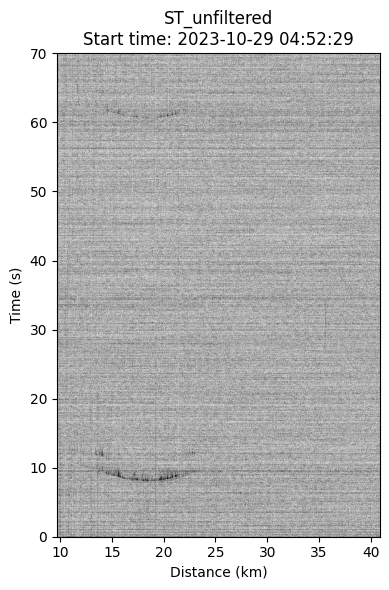

In [ ]:
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_unfiltered")

There is something visible, but we need to enhance the signal.

Let's apply a bandpass filter between 10 Hz and 40 Hz, and repeat the envelope calculation.

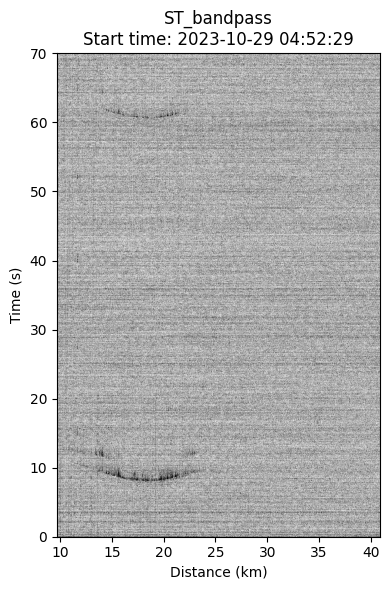

In [ ]:
st.filter(type="bandpass",freqmin=10,freqmax=40,corners=8,zerophase=True)
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_bandpass")

It has improved, but we can go one step further, and get rid of the noise that propagates mechanicaly along the fibre by f-k filtering anything that propagates below 1400 m/s.
To ensure we don't remove any interesting feature, we set `vmax` to 99999 m/s (practical $∞$).

We define the filter as a function, as we'll later use it again.

In [ ]:
def fkfilter(data,vmin=1400,vmax=99999):
  from scipy import ndimage

  print("Return the Discrete Fourier Transform sample frequencies...")
  f = np.fft.fftfreq(nns,d=dt)
  k = np.fft.fftfreq(nnx,d=dx)

  f = np.fft.fftshift(f)
  k = np.fft.fftshift(k)

  print("Compute the 2-dimensional discrete Fourier Transform...")
  ft2 = np.fft.fft2(data)
  ft2s=np.fft.fftshift(ft2)
  del ft2

  print("Return a list of coordinate matrices from coordinate vectors...")
  F,K = np.meshgrid(f,k)
  del f, k

  # Change null values to very small ones to be able to divide afterwards.
  K = np.where(K==0, 1e-10, K)
  C = F/K

  print("Create filter mask...")
  # Create a mask of zeros in the same shape as C.
  filt = np.zeros(C.shape)
  # Create a mask to "mute" entries by replacing zeros with ones where C is in the desired range.
  condition = np.logical_and(np.abs(C) >= vmin, np.abs(C) <= vmax)
  filt[condition] = 1.

  # Blur mask.
  filt_blur = ndimage.gaussian_filter(filt, sigma=10)

  print("Apply mask...")
  ft2_filt = ft2s * filt_blur
  # del fts2
  ft2s_filt = np.fft.ifftshift(ft2_filt)
  del ft2_filt  # to save memory
  # Invert FFT.
  filtered_signal = np.fft.ifft2(ft2s_filt)

  return filtered_signal

Now we apply the f-k filter and recalculate the envelope.

Return the Discrete Fourier Transform sample frequencies...
Compute the 2-dimensional discrete Fourier Transform...
Return a list of coordinate matrices from coordinate vectors...
Create filter mask...
Apply mask...
Background Download Task Finished!


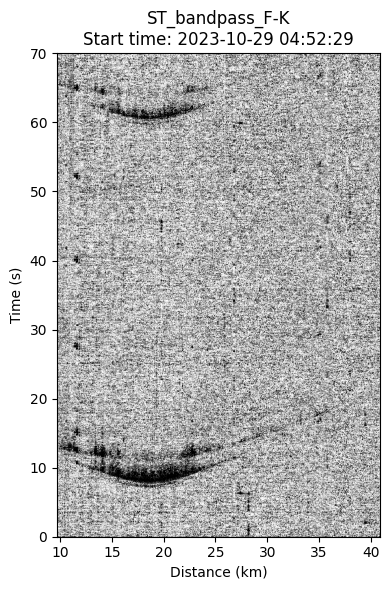

In [ ]:
st=fkfilter(st,vmin=1400,vmax=99999)
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_bandpass_F-K")

Congratulations, you've found whales. The hyperbolic features that dominate the image are blue whale D calls. We can even see the multiple reflections. The tiny blips on the left side are fin whale 20 Hz calls.

# Example #3
## No training wheels
---

Now that we know that we can process DAS data, let's try to repeat the procedure without resorting to OBSpy.

Since now we can't leverage OBSpy directly for the filtering, we have to design a bandpass, zero-phase filter using scipy.

In [ ]:
from scipy.signal import butter, sosfiltfilt

# Use Second-Order Sections (SOS) for better numerical stability
sos = butter(5, [10, 40], analog=False, btype='bandpass', fs=1/dt, output='sos')

# sosfiltfilt applies the filter forward and backward to keep phase at 0
filtered_signal = sosfiltfilt(sos, dfdas.values.astype(float).T)

The rest of the process is similar, and we use the functions we've defined before.

Return the Discrete Fourier Transform sample frequencies...
Compute the 2-dimensional discrete Fourier Transform...
Return a list of coordinate matrices from coordinate vectors...
Create filter mask...
Apply mask...


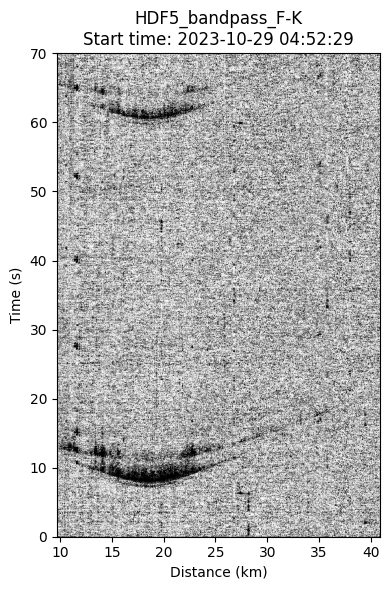

In [ ]:
filtered_signal=fkfilter(filtered_signal,vmin=1400,vmax=99999)
envelope=calculate_hilbert_envelope(filtered_signal)
plot_envelope(envelope,"HDF5_bandpass_F-K")

Compare this image with Figure 16 from Loureiro et al. 2025 (DOI: [10.26443/seismica.v4i2.1482](https://doi.org/10.26443/seismica.v4i2.1482)).

---
The figures were saved as PNG, so you can download them.

We can also annotate the image. The following example is only correct for the original time and channel range of the example.

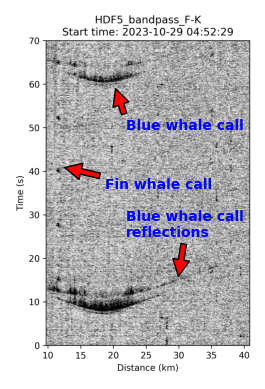

In [ ]:
import matplotlib.image as mpimg

img = mpimg.imread('HDF5_bandpass_F-K.png')
fig, ax = plt.subplots()
ax.imshow(img)

ax.annotate('Blue whale call',
            xy=(500, 370),         # Coordinates for the arrow tip
            xytext=(550, 570),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
ax.annotate(f'Blue whale call\nreflections',
            xy=(800, 1280),         # Coordinates for the arrow tip
            xytext=(550, 1080),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
ax.annotate('Fin whale call',
            xy=(250, 750),         # Coordinates for the arrow tip
            xytext=(450, 850),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
plt.axis('off') # Hide the X/Y axis rulers
plt.savefig('HDF5_bandpass_F-K_annotated.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

---
# **Example #4**
---

We can also run a simple whale detection algorithm on the data.

The first step is to use a template for fin whales. To make it easier, we are providing one. It is compressed and base64-encoded so that we can extract it from a notebook cell. In Colab, files are not persistent.


In [ ]:
compressed_template="eJxFVEluHEEMu/svCbQv//9YWFQbafggD6iFFFXyV77vRy7crZ8/L+7ciC+WEct6EBeJ3iC6VKOCiMpBRjM228C/gKgCrJIPXWIVMw+hGdWdwtjKLHQeehCZvjZmHqh/iJZAc9b2MB9ZTrLhsfISI7MqnRTKCp89cGrJVLGlrYeavLmjEth5Q2WC7voSkePjy8yOQKY422PurWjAO9sw72uZ7qCwzEzxTWtKhX6pI/HJ9qvsSmxM7suc8gJTZvpWrZAaIh2PE8jFujnidLkUe3Z7vlE47UwBQoEWKnhBZcSxbdiDvkY9AaHtta/ddnv1LJ5ulUdTFLtk+9nebFEOPoLm7DlSAXqPw7itYnquPhblOOsArXaTwCUwRZCb6Cqc4NRtYQmLq6cWVTRHNKixCFaymcOpxtxRkTFUxZ8/3WJMZm4SVWyIIezVo3Y7NvSJM01rJTbBDVZomht/F5DMCRaE8NjUY1k7IOxvx3BJh95iFesYvamyoEQGxU/cCFhSK3u+NlrcFPtUMk7bsqVWGKKQ+zYCAubtZ6uZ0BrWiMQFePrFk4a1sLarg+nQ7dBceRvuUAE2e8MKvLQU1sa9Z9+2wckhS10b3EMvS6OahdvFAnS23oFB4rzU/5bVzMBMJAZ3bcjyMGFB2acUFEDp4VNglbio/MyDVKUH8DxglZt39BT5pjK4dPR7Oqq979bQuXBYT0FJQ5VmdVwL1nlhYX/7xJRGJ2yKhB2nMNQJphL3c6Cs9djeowTXx5lNbJ97rzsQ+D4MjhtNz72Oa9zD4yHCw3AYUUWzplagkTwqhA0jfL8CcRQEk+g9Vt/3DzOrAOg="
decoded = base64.b64decode(compressed_template)
decompressed_template = zlib.decompress(decoded).decode('utf-8')

with open("finwhale_100Hz.txt", 'w', encoding='utf-8') as f:
  f.write(decompressed_template)

In the root folder, you'll find a file named `finwhale_100Hz.txt`. It should have 121 lines, each with a single numerical value.

---

Next, we'll reload the same 70 s of data and convert it into a Stream(), as the detector was built around this Class.

In [ ]:
dfdas = simpledas.load_DAS_files(dasfiles, chIndex, samples,integrate=False)
st=dfdas_to_stream(dfdas)

We'll begin with setting the parameters for the detector.

In [ ]:
# --- Baleen whale call detector ---

# --- USER SETTINGS
# ---------------------------------------------------------------------------
# Detection mode:
# "single" = run on one channel defined by CHANNEL_IDX
# "auto"   = choose automatically the strongest channel and run on that one
# "all"    = run on all channels in the stream
DETECT_MODE = "single"     # "single", "auto", or "all"
CHANNEL_IDX = 337          # used only when DETECT_MODE = "single"

# Initial detection parameters
BAND_DETECT = (15, 25)   # Frequency band used for filtering, amplitude calculation, and peak search
ENV_WIN = 0.2            # Length of the smoothing window applied to the amplitude
THRESH = 4.5             # Detection threshold relative to the median filtered amplitude
MIN_DIST = 8.0           # Minimum spacing between consecutive detections to avoid false positives

# Cross-correlation with a matched filter
TEMPLATE_PATH = "./finwhale_100Hz.txt"
TEMPLATE_FS = 100.0     # Original sampling rate of the template. If different from stream, it is resampled
SEARCH_WIN_SEC = 1.0    # Time window used to search for the best correlation peak
CORR_THRESH = 0.15      # Minimum correlation value required to keep a detection

# Spectrogram parameters
SPEC_SOURCE = "raw"     # Trace used for the spectrogram, "raw" or "filtered" data
SPEC_FMIN = 10          # Frequency interval
SPEC_FMAX = 40
SPEC_NPERSEG = 1042     # Number of samples per spectrogram window
SPEC_NOOVERLAP = 900    # Number of overlapping samples between consecutive windows
SPEC_NFFT = 2048
SPEC_DR = 15            # Display dynamic range in dB below the maximum plotted level
CMAP = "jet"



Next, we define the functions that build the detector.

In [ ]:
# --- GENERAL FUNCTIONS
# ---------------------------------------------------------------------------
def bandpass(x, fs, lo, hi, order=4):
    nyq = 0.5 * fs
    lo = max(0.001, float(lo))
    hi = min(float(hi), nyq * 0.99)
    b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, x)

def rms(x):
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.mean(x**2))

def print_stats(name, values, fmt="{:.3f}"):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(f"{name} Mean:    n/a")
        print(f"{name} Median:  n/a")
        print(f"{name} Std:     n/a")
        print(f"{name} min:     n/a")
        print(f"{name} max:     n/a")
        return
    print(f"{name} Mean:    " + fmt.format(np.mean(values)))
    print(f"{name} Median:  " + fmt.format(np.median(values)))
    print(f"{name} Std:     " + fmt.format(np.std(values)))
    print(f"{name} min:     " + fmt.format(np.min(values)))
    print(f"{name} max:     " + fmt.format(np.max(values)))

def centers_to_edges(c, start=None, end=None):
    c = np.asarray(c, dtype=float)
    if len(c) == 1:
        if start is None:
            start = c[0] - 0.5
        if end is None:
            end = c[0] + 0.5
        return np.array([start, end], dtype=float)

    edges = np.empty(len(c) + 1, dtype=float)
    edges[1:-1] = 0.5 * (c[:-1] + c[1:])

    if start is None:
        start = c[0] - 0.5 * (c[1] - c[0])
    if end is None:
        end = c[-1] + 0.5 * (c[-1] - c[-2])

    edges[0] = start
    edges[-1] = end
    return edges

def trace_label(tr, idx):
    station = getattr(tr.stats, "station", "")
    if station:
        return station
    return f"channel_{idx}"

def prepare_template(fs):
    tpl = np.loadtxt(TEMPLATE_PATH).astype(np.float64)
    tpl -= tpl.mean()

    if TEMPLATE_FS != fs:
        tpl = resample_poly(
            tpl,
            up=int(round(fs)),
            down=int(round(TEMPLATE_FS))
        ).astype(np.float64)
        tpl -= tpl.mean()

    n_tpl = len(tpl)
    pulse_width = (n_tpl - 1) / fs
    half_pulse_samp = int(round(0.5 * pulse_width * fs))
    n_search_window = int(round(SEARCH_WIN_SEC * fs))

    # zero + master + zero
    tpl_plus = np.concatenate([np.zeros(n_tpl), tpl, np.zeros(n_tpl)])

    return tpl, tpl_plus, n_tpl, half_pulse_samp, n_search_window

def auto_choose_channel(stream):
    peaks = []
    for i, tr in enumerate(stream):
        x_raw = tr.data.astype(np.float64)
        fs = float(tr.stats.sampling_rate)
        x_det = bandpass(x_raw, fs, *BAND_DETECT)
        peaks.append(np.nanmax(np.abs(x_det)))
    return int(np.nanargmax(peaks))

def process_trace(tr, idx):
    x_raw = tr.data.astype(np.float64)
    fs = float(tr.stats.sampling_rate)
    start_time = tr.stats.starttime.datetime
    channel_label = trace_label(tr, idx)

    tpl, tpl_plus, n_tpl, half_pulse_samp, n_search_window = prepare_template(fs)

    # Detection trace
    x_det = bandpass(x_raw, fs, *BAND_DETECT)

    env = np.abs(x_det)

    win_n = max(1, int(ENV_WIN * fs))
    amp_smooth = np.convolve(env, np.ones(win_n) / win_n, mode="same")

    thr = THRESH * np.median(env)
    dist = max(1, int(MIN_DIST * fs))

    raw_picks, _ = find_peaks(
        amp_smooth,
        height=thr,
        distance=dist
    )

    results = []

    for p in raw_picks:
        approx_start = max(0, p - half_pulse_samp)

        i0 = approx_start - n_tpl
        i1 = approx_start + 2 * n_tpl

        if i0 < 0 or i1 > len(x_det):
            continue

        st2 = x_det[i0:i1]

        if len(st2) != len(tpl_plus):
            continue

        cc = obspy_cc(
            st2,
            tpl_plus,
            n_search_window,
            normalize="naive",
            method="direct",
            demean=True
        )

        i_max = int(np.argmax(cc))
        master_corr = float(np.max(cc))
        master_shift = (i_max - n_search_window) / fs

        if master_corr < CORR_THRESH:
            continue

        refined_start = approx_start + (i_max - n_search_window)

        sig0 = refined_start
        sig1 = refined_start + n_tpl
        noi0 = refined_start - n_tpl
        noi1 = refined_start

        if noi0 < 0 or sig1 > len(x_det):
            continue

        signal_win = x_det[sig0:sig1]
        noise_win = x_det[noi0:noi1]

        amp_max = float(np.max(np.abs(signal_win)))
        signal_rms = float(rms(signal_win))
        noise_rms = float(rms(noise_win))
        snr = np.nan if noise_rms == 0 else signal_rms / noise_rms

        tsec = refined_start / fs
        abs_time = start_time + timedelta(seconds=float(tsec))

        results.append({
            "sample": int(refined_start),
            "time_s": float(tsec),
            "datetime": abs_time,
            "corr": float(master_corr),
            "shift_s": float(master_shift),
            "amp_max": float(amp_max),
            "signal_rms": float(signal_rms),
            "noise_rms": float(noise_rms),
            "snr": float(snr),
        })

    return {
        "idx": idx,
        "label": channel_label,
        "fs": fs,
        "start_time": start_time,
        "x_raw": x_raw,
        "x_det": x_det,
        "amp_smooth": amp_smooth,
        "thr": thr,
        "raw_picks": raw_picks,
        "results": results,
    }

def choose_plot_result(processed):
    if len(processed) == 1:
        return processed[0]

    # Prefer the channel with the most kept detections
    kept_counts = [len(p["results"]) for p in processed]
    if np.max(kept_counts) > 0:
        return processed[int(np.argmax(kept_counts))]

    # If none kept, use the one with most raw picks
    raw_counts = [len(p["raw_picks"]) for p in processed]
    return processed[int(np.argmax(raw_counts))]

Now we run the detector.

Detection mode       : single
Chosen channel index : 337
Chosen channel label : 11423
Sampling rate        : 500.0 Hz
Frequency BW         : (15, 25) Hz
ENV_WIN              : 0.2 s
Raw picks            : 5
Kept detections      : 5
01 | t =   12.32 s | 2023-10-29 04:52:41.320000 | Cmax = 0.329 | Shift = 0.264 s | Amp = 0.000 | Signal RMS = 0.000 | Noise RMS = 0.000 | SNR = 1.88
02 | t =   27.35 s | 2023-10-29 04:52:56.354000 | Cmax = 0.248 | Shift = 0.436 s | Amp = 0.000 | Signal RMS = 0.000 | Noise RMS = 0.000 | SNR = 2.20
03 | t =   39.92 s | 2023-10-29 04:53:08.922000 | Cmax = 0.186 | Shift = 0.436 s | Amp = 0.000 | Signal RMS = 0.000 | Noise RMS = 0.000 | SNR = 1.79
04 | t =   51.98 s | 2023-10-29 04:53:20.980000 | Cmax = 0.275 | Shift = 0.420 s | Amp = 0.000 | Signal RMS = 0.000 | Noise RMS = 0.000 | SNR = 2.36
05 | t =   64.85 s | 2023-10-29 04:53:33.850000 | Cmax = 0.225 | Shift = 0.552 s | Amp = 0.000 | Signal RMS = 0.000 | Noise RMS = 0.000 | SNR = 1.40
***********************

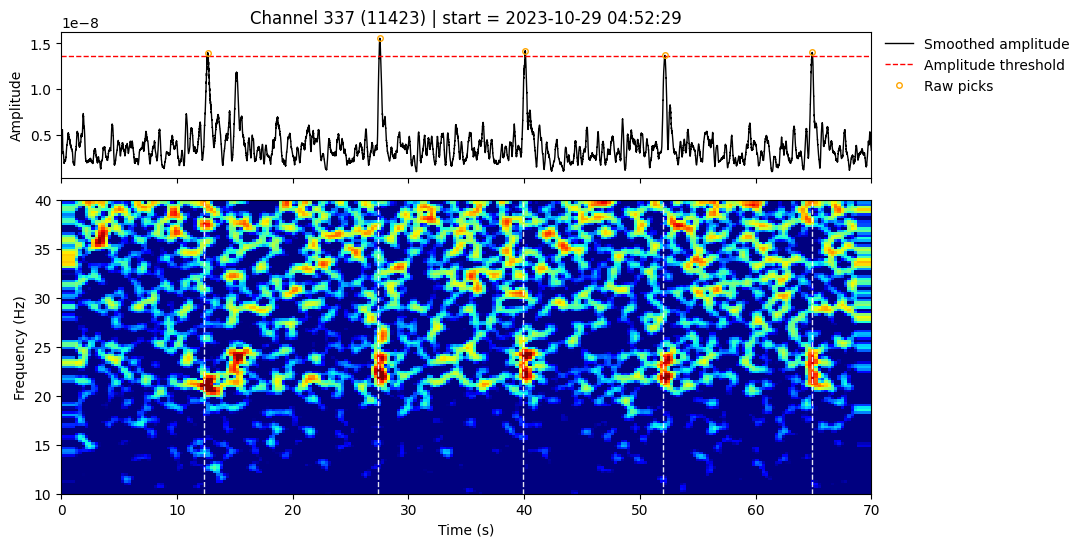

In [ ]:

# --- BASIC CHECKS
# ---------------------------------------------------------------------------
if st==None or len(st) == 0:
    raise RuntimeError("Stream 'st' is empty.")

if not os.path.exists(TEMPLATE_PATH):
    raise FileNotFoundError(f"Template not found: {TEMPLATE_PATH}")

# --- CHANNEL SELECTION
# ---------------------------------------------------------------------------
if DETECT_MODE not in ("single", "auto", "all"):
    raise ValueError("DETECT_MODE must be 'single', 'auto', or 'all'")

if DETECT_MODE == "single":
    if CHANNEL_IDX is None:
        raise ValueError("Set CHANNEL_IDX when DETECT_MODE = 'single'")
    if CHANNEL_IDX < 0 or CHANNEL_IDX >= len(st):
        raise IndexError(f"CHANNEL_IDX out of range: {CHANNEL_IDX}")
    process_indices = [CHANNEL_IDX]

elif DETECT_MODE == "auto":
    auto_idx = auto_choose_channel(st)
    process_indices = [auto_idx]

else:  # DETECT_MODE == "all"
    process_indices = list(range(len(st)))


# --- RUN DETECTOR
# ---------------------------------------------------------------------------
processed = []
for idx in process_indices:
    processed.append(process_trace(st[idx], idx))

# Channel used for plotting
plot_result = choose_plot_result(processed)

# Flatten all kept detections for global summary
all_results = []
for p in processed:
    for rec in p["results"]:
        rec2 = rec.copy()
        rec2["channel_idx"] = p["idx"]
        rec2["channel_label"] = p["label"]
        all_results.append(rec2)


# --- OUTPUT
# ---------------------------------------------------------------------------
if DETECT_MODE in ("single", "auto"):
    p = processed[0]
    print(f"Detection mode       : {DETECT_MODE}")
    print(f"Chosen channel index : {p['idx']}")
    print(f"Chosen channel label : {p['label']}")
    print(f"Sampling rate        : {p['fs']:.1f} Hz")
    print(f"Frequency BW         : {BAND_DETECT} Hz")
    print(f"ENV_WIN              : {ENV_WIN} s")
    print(f"Raw picks            : {len(p['raw_picks'])}")
    print(f"Kept detections      : {len(p['results'])}")

    for i, rec in enumerate(p["results"], start=1):
        print(
            f"{i:02d} | t = {rec['time_s']:7.2f} s | {rec['datetime']} | "
            f"Cmax = {rec['corr']:.3f} | Shift = {rec['shift_s']:.3f} s | "
            f"Amp = {rec['amp_max']:.3f} | Signal RMS = {rec['signal_rms']:.3f} | "
            f"Noise RMS = {rec['noise_rms']:.3f} | SNR = {rec['snr']:.2f}"
        )

else:
    print(f"Detection mode       : {DETECT_MODE}")
    print(f"Processed channels   : {len(processed)}")
    print(f"Frequency BW         : {BAND_DETECT} Hz")
    print(f"ENV_WIN              : {ENV_WIN} s")
    print()

    nonzero = [p for p in processed if (len(p["raw_picks"]) > 0 or len(p["results"]) > 0)]
    print(f"Channels with picks  : {len(nonzero)}")
    print(f"Total kept detections: {len(all_results)}")
    print()

    # Print concise summary only for channels with at least one raw or kept detection
    for p in nonzero:
        print(
            f"idx={p['idx']:5d} | label={p['label']} | "
            f"raw={len(p['raw_picks']):3d} | kept={len(p['results']):3d}"
        )

# --- SUMMARY STATS
print("*******************************")
print(f"Number of lines found {len(all_results)}")

if len(all_results) > 0:
    cmax_arr = [r["corr"] for r in all_results]
    shift_arr = [r["shift_s"] for r in all_results]
    snr_arr = [r["snr"] for r in all_results]

    print_stats("Cmax", cmax_arr, "{:.3f}")
    print()
    print_stats("Shift", shift_arr, "{:.3f}")
    print()
    print_stats("SNR", snr_arr, "{:.3f}")


# --- PLOT: DETECTION RESULTS + SPECTROGRAM
# ---------------------------------------------------------------------------
picks = np.array([rec["sample"] for rec in plot_result["results"]], dtype=int)
raw_picks = plot_result["raw_picks"]
amp_smooth = plot_result["amp_smooth"]
thr = plot_result["thr"]
fs = plot_result["fs"]
x_raw = plot_result["x_raw"]
x_det = plot_result["x_det"]
channel_label = plot_result["label"]
channel_idx = plot_result["idx"]
start_time = plot_result["start_time"]

t = np.arange(len(amp_smooth)) / fs
x_spec = x_raw if SPEC_SOURCE == "raw" else x_det

f, tt, Sxx = spectrogram(
    x_spec,
    fs=fs,
    window="hann",
    nperseg=SPEC_NPERSEG,
    noverlap=SPEC_NOOVERLAP,
    nfft=SPEC_NFFT,
    detrend=False,
    scaling="spectrum",
    mode="magnitude"
)

Sxx_db = 20 * np.log10(Sxx + 1e-12)
sel = (f >= SPEC_FMIN) & (f <= SPEC_FMAX)

duration = len(x_spec) / fs
t_edges = centers_to_edges(tt, start=0.0, end=duration)
f_sel = f[sel]
f_edges = centers_to_edges(f_sel)

vmax = np.percentile(Sxx_db[sel, :], 99.9)
vmin = vmax - SPEC_DR

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={"height_ratios": [1, 2]}
)
fig.subplots_adjust(right=0.80, hspace=0.10)

# Top panel: smoothed amplitude
ax0.plot(t, amp_smooth, lw=1.0, color="black", label="Smoothed amplitude")
ax0.axhline(thr, color="red", ls="--", lw=1.0, label="Amplitude threshold")

if len(raw_picks):
    ax0.plot(
        raw_picks / fs,
        amp_smooth[raw_picks],
        "o",
        ms=4,
        mfc="none",
        mec="orange",
        label="Raw picks"
    )

ax0.set_ylabel("Amplitude")
ax0.set_title(f"Channel {channel_idx} ({channel_label}) | start = {start_time}")
ax0.set_xlim(0, duration)
ax0.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0,
    frameon=False
)

# Bottom panel: spectrogram
ax1.pcolormesh(
    t_edges,
    f_edges,
    Sxx_db[sel, :],
    shading="flat",
    cmap=CMAP,
    vmin=vmin,
    vmax=vmax
)

ax1.set_ylim(SPEC_FMIN, SPEC_FMAX)
ax1.set_xlim(0, duration)
ax1.set_ylabel("Frequency (Hz)")
ax1.set_xlabel("Time (s)")

for p in picks:
    ax1.axvline(p / fs, color="white", ls="--", lw=1.0, alpha=0.9)

plt.setp(ax0.get_xticklabels(), visible=False)
plt.savefig('Whale_detector.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

Since we still the variable `envelope`in memory, we can combine the envelope plot with the spectral detection results.

In [ ]:
def plot_combined_das(data, sxx_db, t_edges, f_edges, vmin, vmax, filename=None, times=None):
    # Create a 1x2 grid (1 row, 2 columns)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(6, 6), gridspec_kw={'width_ratios': [1, 0.5]})

    # --- LEFT PANEL: DAS Envelope (Distance vs Time) ---
    x_min = dfdas.meta["dx"] * roi_step * min_channel[0] / 1000
    x_max = dfdas.meta["dx"] * roi_step * max_channel[0] / 1000
    y_max_time = dfdas.meta["dt"] * dfdas.meta["dimensionSizes"][0]

    ax0.imshow(data.T, aspect='auto',
               extent=[x_min, x_max, 0, y_max_time],
               origin='lower', norm="log", cmap='Greys', vmin=0.7, vmax=2.0)

    if times is not None:
      for i, t in enumerate(times):
        # Label only the first line so the legend only shows one entry
        label = 'Detections' if i == 0 else ""
        ax0.axhline(y=t,
                   color='red',
                   linestyle='--',
                   linewidth=1,
                   alpha=0.8,
                   label=label)
        ax0.legend(loc='upper right')

    ax0.set_xlabel('Distance (km)')
    ax0.set_ylabel('Time (s)')
    ax0.set_title("DAS Envelope")

    # --- RIGHT PANEL: Spectrogram (Frequency vs Time) ---
    # We transpose Sxx_db and swap t/f edges so Time stays on the Y-axis
    pcm = ax1.pcolormesh(
        f_edges,    # X-axis: Frequency
        t_edges,    # Y-axis: Time
        sxx_db.T,   # Transposed to match Y=Time
        shading="flat",
        cmap='jet', # Or your CMAP variable
        vmin=vmin,      # Or your vmin variable
        vmax=vmax        # Or your vmax variable
    )

    if times is not None:
        for t in times:
            ax1.axhline(y=t,
                        color='red',
                        linestyle='--',
                        linewidth=1,
                        alpha=0.8)

    ax1.set_xlim(SPEC_FMIN, SPEC_FMAX)
    ax1.set_ylim(0, y_max_time) # Ensure Time scale matches ax0
    ax1.invert_xaxis()
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_title("Spectrogram")
    ax1.tick_params(axis='y', which='both', left=True, right=True, labelleft=False, labelright=True)
    ax0.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=False)

   # Add a colorbar for the spectrogram
   # plt.colorbar(pcm, ax=ax1, label='dB')

    plt.suptitle(f"{filename}\nStart: {dfdas.meta['time']}")
    plt.tight_layout()

    if filename:
        fig.savefig(f'{filename}_combined.png', dpi=300, bbox_inches='tight')

    plt.show()

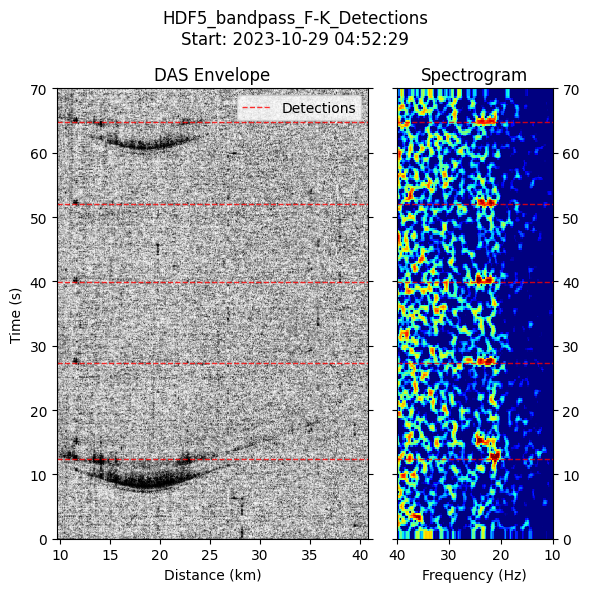

In [ ]:
detection_times_list=[result['time_s'] for result in all_results]
plot_combined_das(envelope,\
                  Sxx_db[sel,:], t_edges, f_edges,\
                  vmin, vmax,\
                  filename="HDF5_bandpass_F-K_Detections",\
                  times=detection_times_list)

Pay close attention to the first detection. It is a false positive for fin whales. The spectral signature is different from the rest. This is actually the blue whale D call, which arrives a few seconds ahead.
Although we used a template for fin whales, the frequency bands for both types of vocalizations have a slight overlap.

There is also a false negative for a fin whale call. When we look at the detector results, there was a peak that almost crossed the amplitude threshold, right after the blue whale call.
However, we can see that it has a similar frequency content than the remaining fin whale detections.

---
# **Example #5**
---

Let's have a closer look at the coast.

We have to download more data, as 70 s are good to spot whales, but not ideal for coastal processes.

We'll repeat the first cells, and use `simpledas` to load some channels.

Earlier, we set a background download task. We need to wait for it to finish before we can load the data.

Note that we are using the `background_starttime` and `background_endtime` values we defined before starting the download task.

Since resources are limited, we also free up the memory taken up by the `Stream()` version of the data. It will not be needed any more.

In [ ]:
print(f"Checking if background download is finished.\n")
download_thread.join()
print("Thread stopped! Loading data.\n\n")

# free some memory
st=None

# define start and end channels, and also an extra decimation step (if needed)
min_channel= [460] # these are numbered according to the number of columns in the file
max_channel= [560] # the internal channel numbering is different
channel_step= [1]

channels = []
for min_chan, max_chan, step_chan in zip(min_channel, max_channel, channel_step):
        top = (max_chan + 1) * roi_step if (max_chan + 1) < last_chan else last_chan
        channels.extend(np.arange(min_chan * roi_step, top, step_chan * roi_step))
        channels = np.array(channels)

# we calculate the duration from the start and end times
duration_timedelta = background_endtime - background_starttime

print(f'Loading {duration_timedelta} minutes of data from {len(channels)} channels, starting at {background_starttime}.')

dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                                  channels=channels,\
                                                  start=background_starttime,\
                                                  duration=duration_timedelta,\
                                                  show_header_info=True,\
                                                  load_file_from_start=True)
dfdas = simpledas.load_DAS_files(dasfiles, chIndex, samples,integrate=False)

print('Sanity check:')
print(f'Loaded {dfdas.meta['dimensionSizes'][0]} samples, from {dfdas.meta['dimensionSizes'][1]} channels, at a sampling rate of {1/dfdas.meta['dt']} Hz.')
print(f'Corresponding to {dfdas.meta['dimensionSizes'][0]*dfdas.meta['dt']} seconds of data, starting at {dfdas.meta['time']}.')


Checking if background download is finished.

Thread stopped! Loading data.


Loading 0:30:00 minutes of data from 101 channels, starting at 2023-10-27 17:02:30.
-- Header info file: 170229.hdf5 --
	Experiment:            SN044_PHASE_26_10_2023
	File timestamp:        2023-10-27 17:02:29
	Type of data:          Phase rate per distance, unit: rad/(s*m)
	Sampling frequency:    500.00 Hz
	Data shape:            5000 samples x 11380 channels
	Gauge length:          10.2 m
	Sensitivities:         9.36e+06 rad/(strain*m)
	Regions of interest:   0:56895:5
	101 channels requested:[2300 2305 2310 ... 2790 2795 2800]
	101 channels found:    [2300 2305 2310 ... 2790 2795 2800]
-----------------------------------
Sanity check:
Loaded 900000 samples, from 101 channels, at a sampling rate of 500.0 Hz.
Corresponding to 1800.0 seconds of data, starting at 2023-10-27 17:02:29.


Full resolution data is too heavy, and the features we are interested in occur at periods longer than 1 s, so we dowsample the data.

However, to avoid numerical instabilities, we cannot directly downsample the data by a factor of 500. In practice, we never use factors above 10, so we need to do it in steps. For that, we adapt the previous downsampling routine to work through a series of downsampling steps.

In [ ]:
downsample_factors=[5,5,5,4] # 500 Hz->100 Hz ; 100 Hz->20 Hz ; 20 Hz-> 4 Hz; 4 Hz-> 1 Hz

for downsample_factor in downsample_factors:
  print(f'Original sampling rate: {1/dfdas.meta["dt"]} Hz\nDownsampling by a factor of {downsample_factor}')
  Nt_in = dfdas.shape[0]
  sig_downsampled = sps.resample_poly(dfdas, up=1, down=downsample_factor, axis=0, padtype='edge')
  Nt_out = sig_downsampled.shape[0]
  dt_out = dfdas.meta['dt'] * Nt_in / Nt_out
  t = simpledas.create_time_axis(tstart, sig_downsampled.shape[0], dt_out)
  meta_out = dfdas.meta.copy()
  meta_out.update(dt=dt_out, time=tstart)
  dfdas = simpledas.DASDataFrame(sig_downsampled,\
                                          index=t,\
                                          columns=dfdas.columns,\
                                          meta=meta_out)
  print(f"New sampling rate: {1/dfdas.meta["dt"]} Hz")

Original sampling rate: 500.0 Hz
Downsampling by a factor of 5
New sampling rate: 100.0 Hz
Original sampling rate: 100.0 Hz
Downsampling by a factor of 5
New sampling rate: 20.0 Hz
Original sampling rate: 20.0 Hz
Downsampling by a factor of 5
New sampling rate: 4.0 Hz
Original sampling rate: 4.0 Hz
Downsampling by a factor of 4
New sampling rate: 1.0 Hz


We'll define a plotting function to be re-used

In [ ]:
def plot_dispersion(disdata,filename=None,tdpc=None,tdpc_complex=None,current=None,inc_ang=None):

  fig, ax = plt.subplots(figsize=(9,6))
  extend=.5e-2
  im = ax.imshow(abs(disdata), aspect='auto', extent=[-min(k), -max(k), 0, max(fft_freqs)], clim=(0, extend))
  if tdpc is not None:
    ax.plot(kk,tdpc,'w--', lw=.75, label='Theoretical dispersion curve')
  if tdpc_complex is not None:
    ax.plot(kk,tdpc_complex,'r--', lw=.75, label=f'{current} m/s current and {inc_ang} degree wave incidence angle influence')
  if tdpc is not None or tdpc_complex is not None:
    ax.legend()

  ax.set_xlabel('Wavenumber (1/m)')
  ax.set_ylabel('Frequency (Hz)')
  ax.invert_xaxis()

  plt.tight_layout()
  if filename is not None:
    fig.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
  plt.show()
  plt.close()

We will now take this half hour of channel data close to the coast.

First, we Fourier Transform the data.

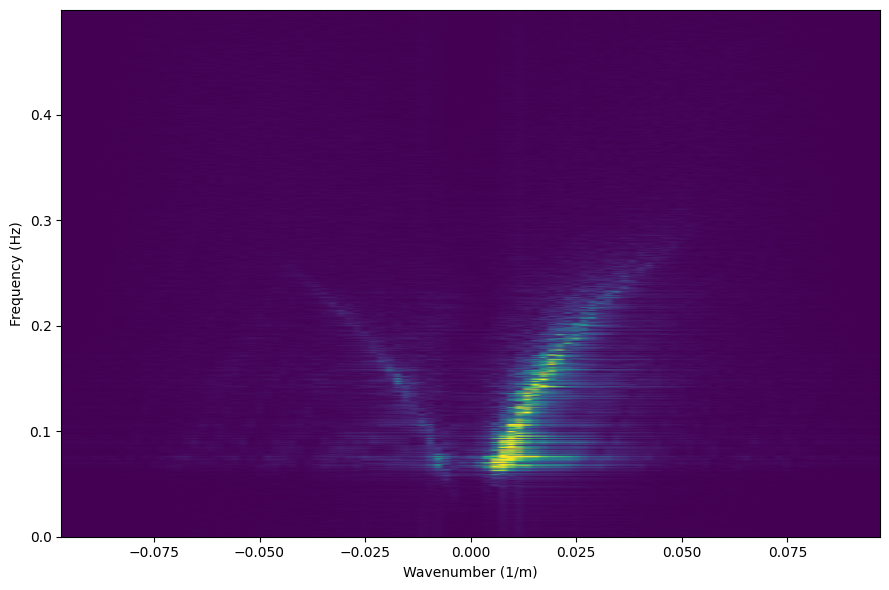

In [ ]:
rawData = np.transpose(dfdas)

# Remove the mean from each individual channel.
nns_rawData = np.shape(rawData)[1]
mn = np.tile(np.mean(rawData,axis=1),(nns_rawData,1)).T
dfdas_mean = rawData - mn

fs = 1

# Interval steps in x direction (we take every value, therefore it is 1).
xint = 1

# Number of rows and columns (distance and time) in the data set.
nnx = dfdas_mean.shape[0]
nns = dfdas_mean.shape[1]

# Return the Discrete Fourier Transform sample frequencies.
f = np.fft.fftfreq(nns,d=1/fs*np.sqrt(2*np.pi))
k = np.fft.fftfreq(nnx,d=dx*roi_step*xint)
f = np.fft.fftshift(f)
k = np.fft.fftshift(k)
fft_freqs = np.fft.fftfreq(nns, d=1.0)

# Compute the 2-dimensional discrete Fourier Transform.
ft2 = np.fft.fft2(dfdas_mean)
ft2s = np.fft.fftshift(ft2)

disdata = ft2s.T[0:int(nns/2),:]

# plotting
plot_dispersion(disdata,filename='Dispersion_curves_for_landward_and_seaward_waves')


In the above figure, we can see two branches of higher energy in f-k space. These are the typical dispersion curves for ocean waves near the coast.

The f-k space is particularely interesting, because it divides influences on the cable by apparent direction along the cable. That means, everything with positive wavenumbers shows apparent movement towards the coast (landward), everything with negative wavenumbers shows apparent movement away from the coast (seaward).

We can see that the amplitudes are higher on the landward side, since the landward waves are generally stronger. Still, both sides show typical dispersion curve behaviour.

*Interesting side note: if you, for example, take some land data (feel free to experiment with the channels between 0 and 450, which are on land), you will get a completely different image. What can be seen on the data there are the vehicles on the roads along which the cable is placed, and you could use this to calculate average vehicle velocities.*

In our case, we will now continue to use the marine channels and overlay a theoretical dispersion curve, using a simple symmetrical case.

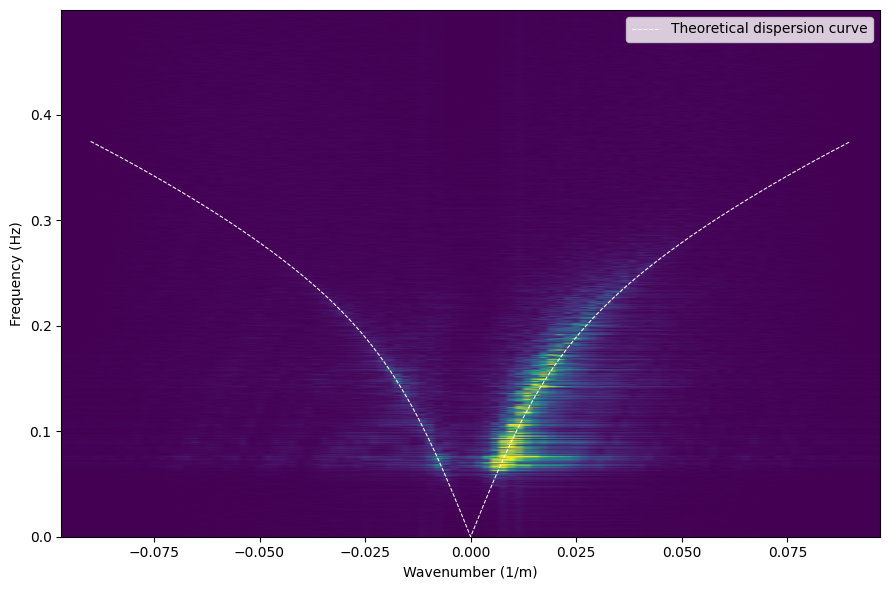

In [ ]:
# Introduce some values for a theoretical dispersion curve.
kk = np.arange(-0.09,0.09,0.0001) # Create an axis in wavenumber-direction.
g = 9.81
z_sf = 10 # Estimation of average seafloor depth in the interval in m.
tdpc = np.sqrt(2*np.pi*g*kk*np.tanh(2*np.pi*kk*z_sf))/(2*np.pi)

# Plotting again.
plot_dispersion(disdata,filename='Dispersion_theoretical-curves',tdpc=tdpc)


We can see that the theoretical dispersion curve matches the results quite well, but not completely - in part, it can be hard to spot, because of the data resolution. This is because we have multiple effects that can alter the shape of the ideal curve. It would be too complicated to try to factor everything in, especially since complexities in shallow waters are extremely hard to quantify. But there are some general factors that affect the curves in a predictable manner, which we can use: apparent oceanic current along the cable and wave incidence angle on the cable.

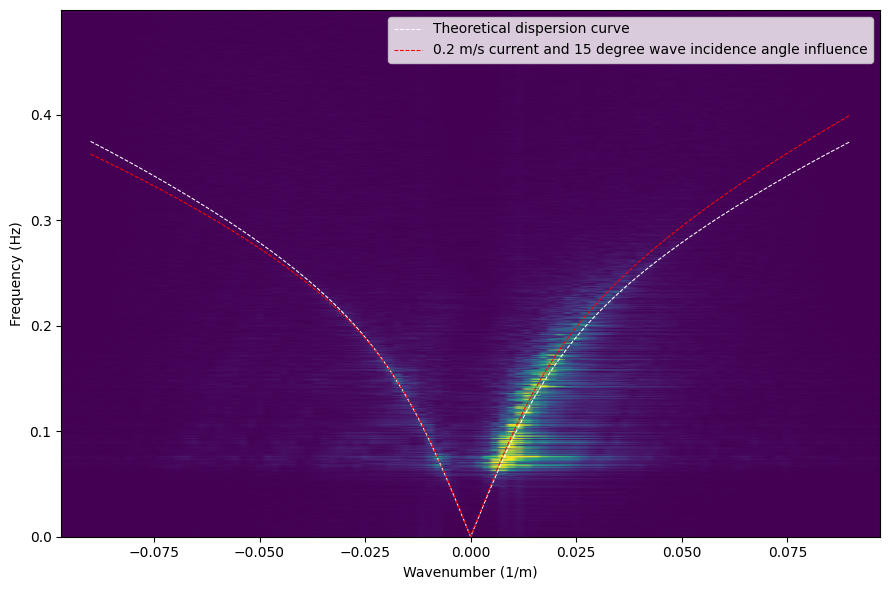

In [ ]:
# Define the incidence angle (deg).
inc_ang = 15
#inc_ang = 45  # to test more extreme values

# Define the current along the cable (m/s).
o_curr = 0.2
#o_curr = 0.4  # to test more extreme values

incc = np.cos(inc_ang/180*np.pi)
tdpc_complex=(np.sqrt(2*np.pi*g*kk/incc*np.tanh(2*np.pi*kk/incc*z_sf))+o_curr*2*np.pi*kk/incc)/(2*np.pi)

# Plotting again.
plot_dispersion(disdata,filename=f'Dispersion_{o_curr}-current_{inc_ang}-wave-angle',tdpc=tdpc,tdpc_complex=tdpc_complex,current=o_curr,inc_ang=inc_ang)


One problem we have when it comes to signal strength is the trade-off between temporal and spatial selections:
*   If we take a longer time interval to increase the signal, the temporal change of the sea state (tides, ocean currents, significant wave height, wave direction, further complex behaviour in shallow waters,...) will cause a smearing of the data, thus reducing our resolution again.
*   If we take a larger number of channels with the same aim as before, we will get a smearing due to spatial changes. In addition, in Madeira, the seafloor depth changes relatively fast and that value has an influence on the dispersion curve, as can be seen in the previous code (parameter: z_sf).
*   If, however, we reduce either the time interval (thus: the number of samples per channel) or the number of channels, the resolution decreases as well.

Therefore, we decided to work with 30-minute intervals here. **Feel free to experiment yourself!** BUT: keep in mind that more data will require more RAM and more computational time.